In [2]:
import pennylane as qml

#BASIS ENCODING
dev = qml.device("default.qubit", range(3))
@qml.qnode(dev)
def circuit(x):
    qml.BasisEmbedding(x, range(3))
    return qml.state()

circuit(6)

array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j])

In [3]:
import pennylane as qml
import numpy as np

#AMPLITUDE ENCODING
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x):
    qml.AmplitudeEmbedding(features=x, wires=range(n_qubits), normalize=True, pad_with=0.)
    return(qml.state())

x_real = np.random.normal(loc=0, scale=1.0, size=2**n_qubits)
x_imag = np.random.normal(loc=0, scale=1.0, size=2**n_qubits)
x = x_real + 1j * x_imag

circuit(x)

array([ 0.00949706+7.35952268e-02j, -0.0443839 -3.86114208e-02j,
        0.01844752-1.70376983e-02j,  0.07833009-5.88148026e-02j,
       -0.04508019-1.18461854e-02j, -0.0291013 -9.34555827e-02j,
        0.04804423+1.49396986e-04j, -0.03475999+3.43938228e-02j,
       -0.08805087-6.61725530e-02j, -0.05328222-5.94743492e-02j,
       -0.04959041-1.74232348e-02j,  0.00246402-3.13166451e-02j,
        0.00955044-2.03743096e-02j, -0.01974571-7.16917714e-03j,
        0.13875479+3.38860123e-02j, -0.0446162 -5.13397943e-03j,
        0.00997848-9.35205128e-02j, -0.0273531 -2.65519688e-02j,
       -0.10974691-3.98822892e-02j,  0.03397262-4.85517347e-02j,
       -0.06962361+4.85077074e-02j,  0.04901329+9.62055979e-03j,
       -0.00752553+3.54183662e-02j, -0.01621057+2.04843359e-02j,
       -0.03897946+5.29611055e-03j, -0.02124757-2.29984637e-03j,
        0.08276581-1.70480233e-02j, -0.00781622-6.71117426e-02j,
       -0.02036572-4.52060601e-03j, -0.0250868 +4.28249980e-03j,
        0.03292643-1.9766

In [4]:
import pennylane as qml
import numpy as np

#ANGLE ENCODING
n_qubits = 8

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit(x):
    qml.AngleEmbedding(features=x, wires=range(n_qubits), rotation="X")
    return(qml.state())

x = np.random.uniform(0, np.pi, (n_qubits))

circuit(x)

array([ 0.00342916+0.j        ,  0.        -0.00124875j,
        0.        -0.00758866j, -0.00276346+0.j        ,
        0.        -0.05625096j, -0.02048414+0.j        ,
       -0.12448208+0.j        ,  0.        +0.04533093j,
        0.        -0.00193713j, -0.00070542+0.j        ,
       -0.00428682+0.j        ,  0.        +0.00156107j,
       -0.03177609+0.j        ,  0.        +0.01157146j,
        0.        +0.07031976j,  0.02560738+0.j        ,
        0.        -0.00245719j, -0.0008948 +0.j        ,
       -0.0054377 +0.j        ,  0.        +0.00198017j,
       -0.040307  +0.j        ,  0.        +0.01467804j,
        0.        +0.08919846j,  0.03248218+0.j        ,
       -0.00138806+0.j        ,  0.        +0.00050547j,
        0.        +0.00307175j,  0.0011186 +0.j        ,
        0.        +0.02276937j,  0.00829161+0.j        ,
        0.05038809+0.j        ,  0.        -0.01834914j,
        0.        -0.00535155j, -0.0019488 +0.j        ,
       -0.01184287+0.j        ,

[ 0.36+0.j  0.  +0.j  0.  +0.j  0.64+0.j -0.48+0.j  0.  +0.j  0.  +0.j
  0.48+0.j]
Post-selected state: [0.36+0.j 0.  +0.j 0.  +0.j 0.64+0.j]
Norm: 0.7343023900274328
Normalized result: [0.4903+0.j 0.    +0.j 0.    +0.j 0.8716+0.j]


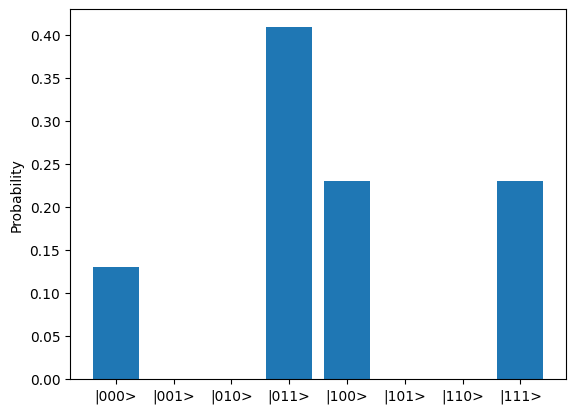

In [5]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

a = 0.36
b = 0.64

A = np.array(
    [[a,  0, 0,  b],
     [0, -a, b,  0],
     [0,  b, a,  0],
     [b,  0, 0, -a]]
)

LCU = qml.pauli_decompose(A)
LCU_coeffs, LCU_ops = LCU.terms()

alphas = (np.sqrt(LCU_coeffs) / np.linalg.norm(np.sqrt(LCU_coeffs)))

dev = qml.device("default.qubit", wires=3)

ops = LCU_ops
unitaries = [qml.map_wires(op, {0: 1, 1: 2}) for op in ops]

@qml.qnode(dev)
def lcu_circuit():
    qml.StatePrep(alphas, wires=0)
    qml.Select(unitaries, control=0)
    qml.adjoint(qml.StatePrep(alphas, wires=0))
    return(qml.state())

state = lcu_circuit()
print(state)

# Reshape into (ancilla, target_system)
# qubit 0 is ancilla, qubits 1-2 are target
state_matrix = state.reshape(2, 4)  # 2 ancilla states, 4 target states

# Post-select: keep only ancilla = |0> part
post_selected = state_matrix[0]

print("Post-selected state:", post_selected)
print("Norm:", np.linalg.norm(post_selected))

# Normalize
result = post_selected / np.linalg.norm(post_selected)
print("Normalized result:", np.round(result, 4))
#print(np.real(np.round(output_matrix,2)))

probs = np.abs(state)**2
labels = [f'|{i:03b}>' for i in range(8)]
plt.bar(labels, probs)
plt.ylabel('Probability')
plt.show()